In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
# df['Age'].fillna(df['Age'].median(),inplace=True)

df.fillna({'Age': df['Age'].median()}, inplace=True)

In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:

df.drop(columns=['Cabin'], inplace=True)



In [25]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [26]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


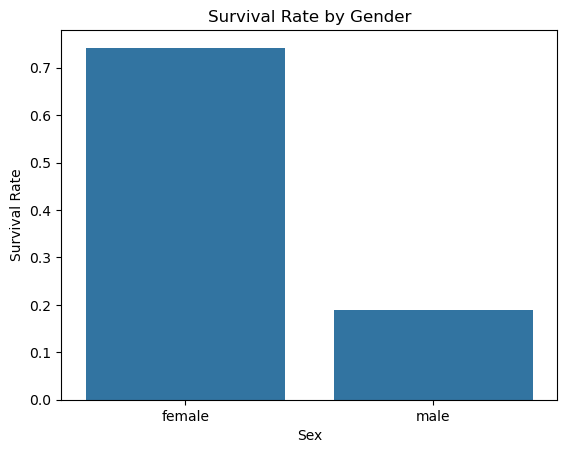

In [27]:
# Survival count by gender
gender_survival = df.groupby('Sex')['Survived'].mean()
print(gender_survival)

# Visualization
sns.barplot(x=gender_survival.index, y=gender_survival.values)
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Gender')
plt.show()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


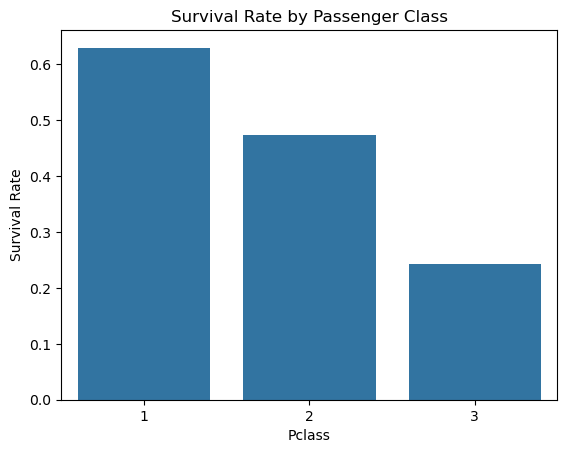

In [28]:
# Survival rate by passenger class
class_survival = df.groupby('Pclass')['Survived'].mean()
print(class_survival)

# Visualization
sns.barplot(x=class_survival.index, y=class_survival.values)
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class')
plt.show()

AgeGroup
Child         0.579710
Teen          0.428571
Adult         0.353271
Middle Age    0.400000
Senior        0.227273
Name: Survived, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_14192\2207802852.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agegroup_survival = df.groupby('AgeGroup')['Survived'].mean()


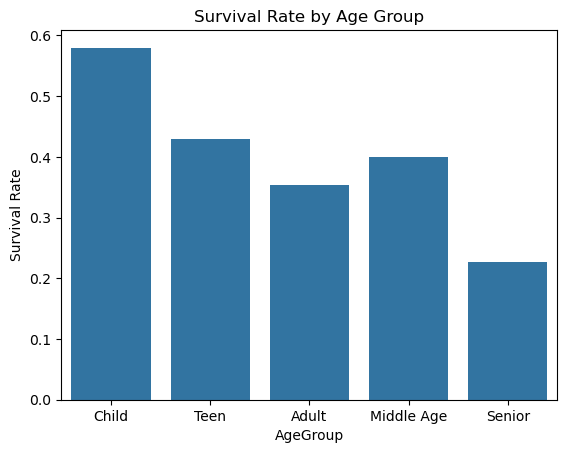

In [29]:
# Create age groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Survival rate by age group
agegroup_survival = df.groupby('AgeGroup')['Survived'].mean()
print(agegroup_survival)

# Visualization
sns.barplot(x=agegroup_survival.index, y=agegroup_survival.values)
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age Group')
plt.show()

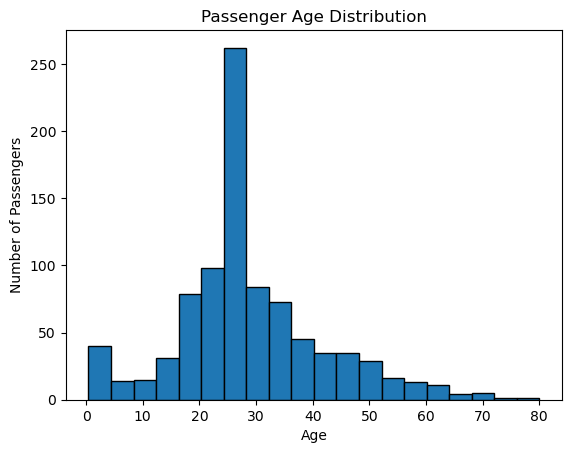

In [30]:
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Passenger Age Distribution')
plt.show()

Gender: Females had a higher survival rate than males.
Passenger Class: 1st class passengers survived more than 2nd and 3rd class.
Age Groups: Children and young adults had slightly higher survival rates.
Visualization: Bar charts and histograms clearly show survival trends.